# 3. Convergencia Beta (β)

Aqui analizo si los países más pobres crecen más rápido que los más ricos por medio del modelo de convergencia beta.

Segun la hipótesis los países con menor nivel inicial de desarrollo deberían crecer más rápido debido a rendimientos decrecientes del capital de los paises ya desarrollados.

La formula es:

$$\text{CAGR}_{i} = \alpha + \beta \cdot \ln(\text{PIBpc}_{i,0}) + \varepsilon_{i}$$
 

CAGR: (Tasa de Crecimiento Anual Compuesta): Es la velocidad promedio a la que ha corrido el país durante todo el periodo analizado (por ejemplo, desde 2004 hasta hoy).

lnPIBpc_0: (Logaritmo del PIB per cápita inicial): Es la posición de salida del país. Nos dice qué tan rico o pobre era el país al principio del estudio (el año cero). Se usa el logaritmo simplemente para que los números gigantes del PIB se puedan comparar de forma justa y lineal.

Beta: es el coeficiente que determina si hay convergencia ( -β, la distancia disminuye) o divergencia (+β la brecha aumenta)

Alfa: Constante que representa la velocidad base a la que crecería un país si su nivel de riqueza inicial fuera neutro.

Epsilon: "error" factores externos imprevistos que afectan al crecimiento (como una pandemia, una reforma interna o una guerra).

En la gráfica:

**Eje X**: ln(PIB per cápita en 2004) — nivel de partida (más a la derecha = más rico)
**Eje Y**: CAGR 2004-2023 — velocidad de crecimiento (más arriba = más rápido)

Si hay convergencia beta, los puntos forman una línea descendiente:
- Arriba-izquierda: país pobre que crece rápido (Polonia)
- Abajo-derecha: país rico que crece lento (República Checa)"


In [ ]:
import sys
import os
from scipy import stats

# Detectar src/ automáticamente: sube desde notebooks/v1.0/ → raíz del proyecto
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
SRC_PATH = os.path.join(PROJECT_ROOT, "src")

sys.path.insert(0, SRC_PATH)

# print(f"Project root: {PROJECT_ROOT}")
# print(f"src: {SRC_PATH}")
# print(f"Existe: {os.path.exists(os.path.join(SRC_PATH, 'config.py'))}")

from config import UE14, V4, COLORES_V4, NOMBRES_PAIS, AÑO_INICIO_DEFAULT, AÑO_FIN_DEFAULT
from db_utils import load_convergencia_data
from plotting_utils import setup_plot_style, save_figure

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

setup_plot_style()
# print(" Todo listo")

In [21]:
# Cargar datos
df = load_convergencia_data(paises=V4, años=list(range(AÑO_INICIO_DEFAULT, AÑO_FIN_DEFAULT + 1)))

# Preparar datos para regresión beta
paises_beta = []
ln_y0s = []
cagrs = []

for pais in V4:
    pais_data = df[df['pais'] == pais].sort_values('año')
    y0 = pais_data['valor'].iloc[0]      # PIBpc inicial (2004)
    yf = pais_data['valor'].iloc[-1]     # PIBpc final (2023)
    n = len(pais_data) - 1                # años de diferencia

    cagr = (yf / y0) ** (1/n) - 1         # tasa de crecimiento anual compuesta
    ln_y0 = np.log(y0)                    # logaritmo natural del valor inicial

    paises_beta.append(pais)
    ln_y0s.append(ln_y0)
    cagrs.append(cagr * 100)              # en porcentaje

    print(f"{pais} ({NOMBRES_PAIS[pais]}):")
    print(f"   PIBpc 2004: {y0:,.0f} PPS")
    print(f"   PIBpc 2023: {yf:,.0f} PPS")
    print(f"   CAGR: {cagr*100:.2f}% anual")
    print(f"   ln(PIBpc₀): {ln_y0:.3f}")
    print()

PL (Polonia):
   PIBpc 2004: 10,962 PPS
   PIBpc 2023: 29,520 PPS
   CAGR: 5.35% anual
   ln(PIBpc₀): 9.302

CZ (República Checa):
   PIBpc 2004: 17,135 PPS
   PIBpc 2023: 34,974 PPS
   CAGR: 3.83% anual
   ln(PIBpc₀): 9.749

HU (Hungría):
   PIBpc 2004: 13,280 PPS
   PIBpc 2023: 28,969 PPS
   CAGR: 4.69% anual
   ln(PIBpc₀): 9.494

SK (Eslovaquia):
   PIBpc 2004: 12,370 PPS
   PIBpc 2023: 28,488 PPS
   CAGR: 4.49% anual
   ln(PIBpc₀): 9.423



In [24]:
# Regresión lineal: CAGR vs ln(PIBpc₀)
slope_beta, intercept_beta, r_value, p_value, std_err = stats.linregress(ln_y0s, cagrs)

print("RESULTADOS DE LA REGRESIÓN BETA:")
print(f"β (pendiente): {slope_beta:.4f}")
print(f"α (intercepto): {intercept_beta:.4f}")
print(f"R²: {r_value**2:.4f}")
print(f"p-value: {p_value:.4f}")
print(f"Error estándar: {std_err:.4f}")
print()

# if slope_beta < 0 and p_value < 0.10:
#     print(" CONCLUSIÓN: Convergencia beta confirmada (significativa)")
# elif slope_beta < 0:
#     print("  CONCLUSIÓN: β < 0 pero no significativo (n=4 limita potencia estadística)")
# else:
#     print(" CONCLUSIÓN: No hay evidencia de convergencia beta")

# print(f" Interpretación: Por cada unidad de ln(PIBpc₀), la tasa de crecimiento cambia en {slope_beta:.2f} pp.")


RESULTADOS DE LA REGRESIÓN BETA:
β (pendiente): -3.1240
α (intercepto): 34.2436
R²: 0.8792
p-value: 0.0623
Error estándar: 0.8186



Quiero saber que tan rapido crece polonia, encuentro fue un pais que partio con desventaja al entrar en la UE pero ha tenido tasas de crecimiento sostenibles. 

Encpontre el concepto de convergencia economica que basicamente es "un pais por ser pobre, puede crecer mas rapido que los paises ricos?"

no es la pregunta central que quiero responder en mi estudio pero me sirve para ver la evolucion del PIBpc y su ritmo de crecimiento junto con sus pares (paises V4) frente al promedio europeo.

para ello:
- Necesito una "línea de tendencia", pero puedo entender esa linea como una tendencia? o puede ser el azar?
- para tratar de comprobarlo, necesito calcular el error standard que es ese coeficiente que altera la pendiente de mi analisis lineal.
- Tambien necesito falsear mi hipotesis (H0 = pendiente 0), midiendo que tan lejos estoy de la 'nada' con el El estadístico t.
- 

Significado: Tu pendiente observada (-3.12) está a 3.82 errores estándar de distancia del cero. Es como decir: "La moneda cargada que encontré está 3.82 desviaciones estándar lejos de una moneda justa."
⚖️ ¿Significativo o no? La tabla de decisión
Con solo 2 grados de libertad (n=4 países - 2 parámetros = 2), la distribución t tiene colas muy pesadas (es muy exigente):
Table
Nivel de confianza	Valor crítico	Tu t = 3.82	¿Pasa?
90% (α = 10%)	2.920	3.82 > 2.92	✅ Sí
95% (α = 5%)	4.303	3.82 < 4.303	❌ No
99% (α = 1%)	9.925	3.82 < 9.925	❌ No
Zona gris: Hay evidencia, pero no suficientemente fuerte para estar 95% seguro. Estás en el limbo entre el 90% y 95%.
🎲 El p-value: "¿Probabilidad de engañarme?"
p = 0.0623 (6.23%)
Significado: Si en realidad NO hubiera relación entre pobreza inicial y crecimiento, tendrías un 6.23% de probabilidad de obtener una pendiente tan extrema como -3.12 solo por azar.
Si p < 5% → "Raro que sea azar, probablemente es real"
Si p > 10% → "Probablemente es azar"
Tu p = 6.23% → Zona gris 🔶
🔑 La conclusión final
"Relación fuerte (la pendiente es -3.12, bastante pronunciada), pero confianza estadística limitada por tener solo 4 países."
Es como ver 3 caras en 4 tiros de moneda: sospechas que está cargada, pero no puedes demostrarlo más allá de toda duda razonable. Necesitarías más tiros (más países) para estar seguro.
Table
Si tuvieras...	Resultado con el MISMO β = -3.12
4 países (ahora)	❌ No significativo al 95%
10 países	✅ Significativo al 95%
30 países	✅ Muy significativo
El problema no es la fuerza de la relación, sino la poca evidencia.

🪙 La analogía clave: La moneda cargada
Tiras una moneda 4 veces. Salen 3 caras.
¿La moneda está cargada? Con solo 4 tiros, no puedes estar seguro. Podría ser suerte.
Aquí pasa lo mismo: con solo 4 países, ¿el patrón que ves es real o solo "suerte" de haber elegido estos 4?


1. Calculamos β = -3.12 con n=4 países

2. ¿Es β real o solo azar de la muestra?

3. Calculamos SE(β) = 0.82
   β oscilaría ±0.82 si repitiéramos la muestra

4. Calculamos t = -3.82
   β está 3.82 errores estándar lejos de cero

5. Consultamos distribución t con gl=2
   Valor crítico al 5% = 4.303

6. |3.82| < 4.303 → NO rechazamos H₀ al 5%
   Pero |3.82| > 2.920 → SÍ al 10%

7. p-value = 0.0623 confirma: entre 5% y 10%

8. CONCLUSIÓN: Relación fuerte (R²=0.88) pero con 
   confianza estadística limitada por tamaño muestral

Usé std_err para hallar: 

1.  slope_beta	β (pendiente)
    - Por cada +1 en ln(PIBpc₀), CAGR baja 3.12 pp
2°	intercept_beta	α (intercepto)
    - Valor teórico de CAGR cuando ln(PIBpc₀) = 0
3°	r_value	r (correlación de Pearson)
    - Relación negativa fuerte (signo indica dirección)
4°	p_value	p (significancia de la pendiente)
    - 
5°	std_err	Error estándar de la estimación de β

/var/folders/18/69wzk6cx6f95hjkf9t35y3sw0000gn/T/ipykernel_4894/3859731999.py:33: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


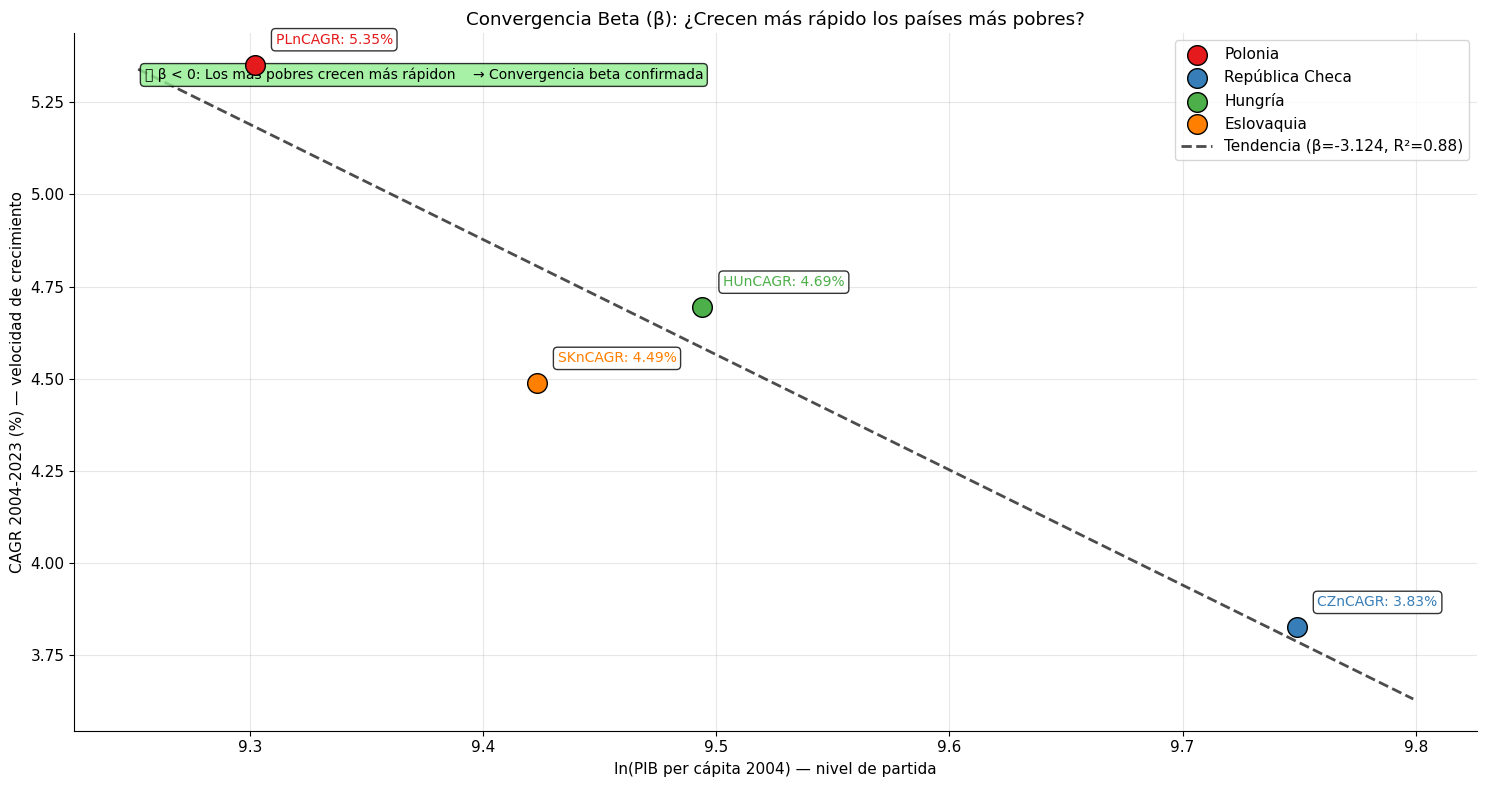

In [ ]:
# Gráfica de convergencia beta
fig, ax = plt.subplots(figsize=(15, 8))

for i, pais in enumerate(paises_beta):
    ax.scatter(ln_y0s[i], cagrs[i], 
               color=COLORES_V4[pais], s=200, 
               label=NOMBRES_PAIS[pais], zorder=5, edgecolors='black')

# Línea de tendencia
x_line = np.linspace(min(ln_y0s) - 0.05, max(ln_y0s) + 0.05, 100)
y_line = slope_beta * x_line + intercept_beta
ax.plot(x_line, y_line, "k--", alpha=0.7, linewidth=2,
        label=f"Tendencia (β={slope_beta:.3f}, R²={r_value**2:.2f})")

# Anotaciones con valores
for i, pais in enumerate(paises_beta):
    ax.annotate(f"{pais}nCAGR: {cagrs[i]:.2f}%", 
                xy=(ln_y0s[i], cagrs[i]),
                xytext=(15, 15), textcoords='offset points',
                fontsize=10, color=COLORES_V4[pais],
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

ax.set_title("Convergencia Beta (β): ¿Crecen más rápido los países más pobres?")
ax.set_xlabel("ln(PIB per cápita 2004) — nivel de partida")
ax.set_ylabel("CAGR 2004-2023 (%) — velocidad de crecimiento")
ax.legend(loc='best')

if slope_beta < 0:
    ax.text(0.05, 0.95, "✅ β < 0: Los más pobres crecen más rápidon    → Convergencia beta confirmada", 
            transform=ax.transAxes, fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))

plt.tight_layout()
save_figure(fig, '03_convergencia_beta.png')
plt.show()

## Interpretación del gráfico

Cada punto representa un país del V4. Su posición en el gráfico nos dice:

- **Horizontalmente (eje X)**: Qué tan pobre era en 2004. Más a la izquierda = más pobre.
- **Verticalmente (eje Y)**: Qué tan rápido creció durante 2004-2023. Más arriba = más rápido.

**La línea de tendencia** muestra la relación entre ambas variables:
- Si baja de izquierda a derecha (β < 0): los países pobres crecen más rápido → **convergencia**
- Si sube de izquierda a derecha (β > 0): los países ricos crecen más rápido → **divergencia**

**Limitación**: Con solo 4 países (V4), la significancia estadística es limitada.
El resultado es más una tendencia descriptiva que una prueba estadística robusta.